# Project 1- Brisa Menautt (DATA 101)
## Research Topic: ICE detainments and arrests
## Research Question: How does a detainee's Citizenship Country correlate with their case status?

## Introduction Paragraph:

### I decided to investigate the relationship between a detainee's country of citizenship to their legal case status in the U.S. Immigration and Customs Enforcement (ICE). I downloaded the data from their website and used the "Arrests-raw.xlsx" dataset. This project explores whether or not certain nationalities experience different outcomes during arrest processes. This research project is significant to me because of the current events in the U.S. This projet will provide real data and help identify patterns in how arrests are processed amongst different nationalities/citizenships groups.

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

#This function creates a dataframe for my data, skipping the first 5 rows because of unmnamed data.
df = pd.read_excel("Arrests_raw.xlsx", skiprows=5)

### This shows how many columns I have.

In [64]:
print(df.columns)
summary.style.set_properties(**{
    'text-align': 'center'
}).set_table_styles([{
    'selector': 'th, td',
    'props': [('border', '1px solid black')]
}])

Index(['ERO Administrative Arrests for 09/01/2023 - 10/15/2025', 'Unnamed: 1',
       'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6',
       'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')


Case_Status,0-Withdrawal Permitted - I-275 Issued,3-Voluntary Departure Confirmed,5-Title 50 Expulsion,6-Deported/Removed - Deportability,7-Died,8-Excluded/Removed - Inadmissibility,9-VR Witnessed,A-Proceedings Terminated,ACTIVE,B-Relief Granted,E-Charging Document Canceled by ICE,L-Legalization - Permanent Residence Granted,Z-SAW - Permanent Residence Granted
Citizenship,,,,,,,,,,,,,
COLOMBIA,11.000000,966.000000,0.000000,776.000000,3.000000,4875.000000,3.000000,62.000000,6090.000000,18.000000,146.000000,2.000000,0.000000
CUBA,11.000000,108.000000,1.000000,499.000000,2.000000,1687.000000,0.000000,663.000000,5492.000000,168.000000,87.000000,80.000000,4.000000
DOMINICAN REPUBLIC,1.000000,491.000000,0.000000,1292.000000,1.000000,2132.000000,26.000000,66.000000,2157.000000,25.000000,94.000000,2.000000,0.000000
ECUADOR,11.000000,963.000000,0.000000,354.000000,0.000000,4254.000000,1.000000,101.000000,6353.000000,30.000000,119.000000,0.000000,0.000000
EL SALVADOR,8.000000,912.000000,0.000000,2056.000000,6.000000,8059.000000,4.000000,73.000000,5613.000000,39.000000,129.000000,3.000000,0.000000
GUATEMALA,12.000000,4635.000000,1.000000,4261.000000,5.000000,25242.000000,93.000000,174.000000,12771.000000,46.000000,450.000000,0.000000,0.000000
HONDURAS,37.000000,2664.000000,0.000000,3960.000000,5.000000,22918.000000,26.000000,121.000000,10558.000000,47.000000,241.000000,1.000000,1.000000
MEXICO,55.000000,11834.000000,0.000000,29435.000000,17.000000,58426.000000,9775.000000,397.000000,29659.000000,310.000000,1261.000000,15.000000,4.000000
NICARAGUA,13.000000,893.000000,2.000000,273.000000,1.000000,5367.000000,5.000000,83.000000,10963.000000,52.000000,123.000000,0.000000,0.000000


## Data Wrangling Technique 1:
### I found that there are a lot of unnamed columns that makes my data hard to read. I renamed the columns that I am going to focus on-- Citizenship and Case Status and printed them.

In [65]:
#This renames the columns that I want to focus on.
df = df.rename(columns={
    'Unnamed: 16': 'Citizenship',
    'Unnamed: 8': 'Case_Status',
})
print(df[['Citizenship', 'Case_Status']].head())

           Citizenship                           Case_Status
0  Citizenship Country                           Case Status
1               MEXICO  8-Excluded/Removed - Inadmissibility
2             HONDURAS  8-Excluded/Removed - Inadmissibility
3             HONDURAS  8-Excluded/Removed - Inadmissibility
4            GUATEMALA  8-Excluded/Removed - Inadmissibility


## Data Wrangling Technique 2:
### Next I will remove any missing data in the citizenship and case status columns.

In [66]:
df_clean = df.dropna(subset=['Citizenship', 'Case_Status'])

## Data Wrangling Technique 3:
### This filters the top 10 countries so I can focus on the trends and more significant factors. I created a data frame for the top 10 countries.

In [67]:
top_10_countries = df_clean['Citizenship'].value_counts().nlargest(10).index
df_plot = df_clean[df_clean['Citizenship'].isin(top_10_countries)]
print(df_plot)

       ERO Administrative Arrests for 09/01/2023 - 10/15/2025  Unnamed: 1  \
1                                     2023-09-23 09:01:00             NaN   
2                                     2023-11-09 11:06:00             NaN   
3                                     2025-09-11 11:58:34      CALIFORNIA   
4                                     2025-07-08 11:06:36             NaN   
5                                     2025-09-23 13:22:06           TEXAS   
...                                                   ...             ...   
377059                                2025-10-15 17:02:46           TEXAS   
377060                                2025-10-15 17:08:04           TEXAS   
377061                                2025-10-15 14:26:37           TEXAS   
377062                                2025-10-15 17:13:42           TEXAS   
377063                                2025-10-15 17:21:46           TEXAS   

       Unnamed: 2                            Unnamed: 3  \
1             Na

### I cleaned the data by skipping header rows, renaming columns for clarity, and filtering for the top 10 countries to focus the analysis. Now all left to do it display it so that we can easily see it.

In [68]:
summary = df_plot.groupby(['Citizenship', 'Case_Status']).size().unstack().fillna(0)
summary.style.set_properties(**{
    'text-align': 'center'
}).set_table_styles([{
    'selector': 'th, td',
    'props': [('border', '1px solid black')]
}])

Case_Status,0-Withdrawal Permitted - I-275 Issued,3-Voluntary Departure Confirmed,5-Title 50 Expulsion,6-Deported/Removed - Deportability,7-Died,8-Excluded/Removed - Inadmissibility,9-VR Witnessed,A-Proceedings Terminated,ACTIVE,B-Relief Granted,E-Charging Document Canceled by ICE,L-Legalization - Permanent Residence Granted,Z-SAW - Permanent Residence Granted
Citizenship,,,,,,,,,,,,,
COLOMBIA,11.000000,966.000000,0.000000,776.000000,3.000000,4875.000000,3.000000,62.000000,6090.000000,18.000000,146.000000,2.000000,0.000000
CUBA,11.000000,108.000000,1.000000,499.000000,2.000000,1687.000000,0.000000,663.000000,5492.000000,168.000000,87.000000,80.000000,4.000000
DOMINICAN REPUBLIC,1.000000,491.000000,0.000000,1292.000000,1.000000,2132.000000,26.000000,66.000000,2157.000000,25.000000,94.000000,2.000000,0.000000
ECUADOR,11.000000,963.000000,0.000000,354.000000,0.000000,4254.000000,1.000000,101.000000,6353.000000,30.000000,119.000000,0.000000,0.000000
EL SALVADOR,8.000000,912.000000,0.000000,2056.000000,6.000000,8059.000000,4.000000,73.000000,5613.000000,39.000000,129.000000,3.000000,0.000000
GUATEMALA,12.000000,4635.000000,1.000000,4261.000000,5.000000,25242.000000,93.000000,174.000000,12771.000000,46.000000,450.000000,0.000000,0.000000
HONDURAS,37.000000,2664.000000,0.000000,3960.000000,5.000000,22918.000000,26.000000,121.000000,10558.000000,47.000000,241.000000,1.000000,1.000000
MEXICO,55.000000,11834.000000,0.000000,29435.000000,17.000000,58426.000000,9775.000000,397.000000,29659.000000,310.000000,1261.000000,15.000000,4.000000
NICARAGUA,13.000000,893.000000,2.000000,273.000000,1.000000,5367.000000,5.000000,83.000000,10963.000000,52.000000,123.000000,0.000000,0.000000


### Lastly, I created a bar chart to visually display and make easier to read.

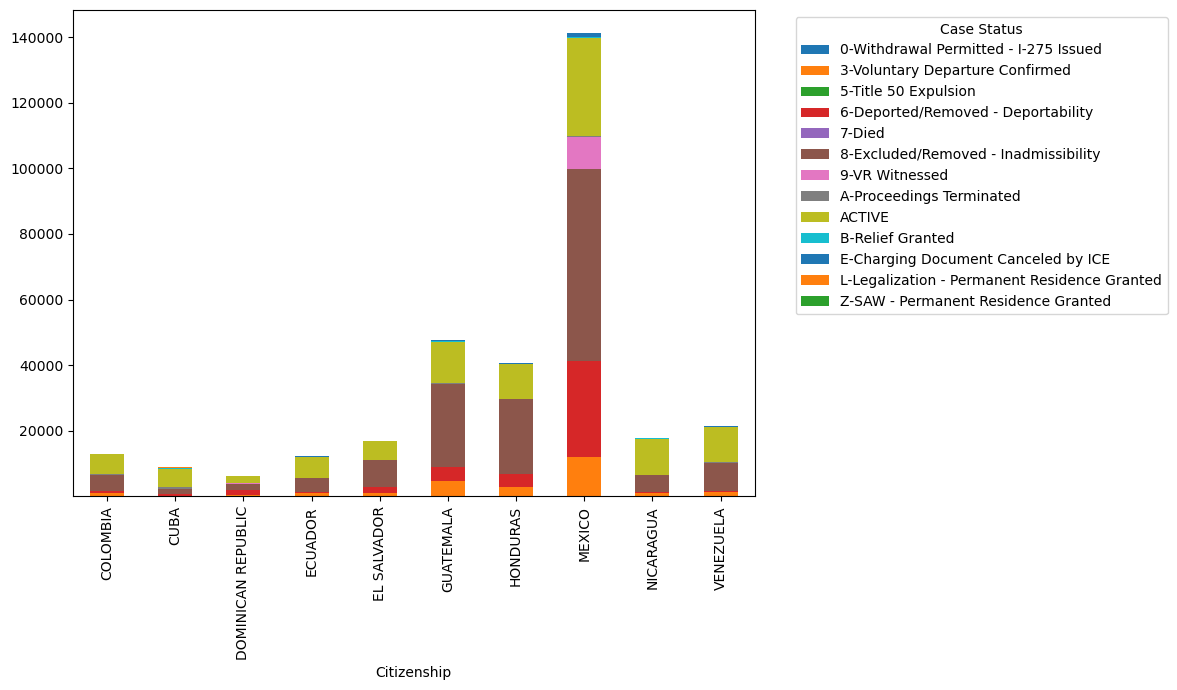

In [69]:
summary.plot(kind='bar', stacked=True, figsize= (12, 7))
plt.legend(title='Case Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Analysis of Findings:
### After exploring the given data set from the U.S. Immigration and Customs Enforcement, the data reveals a significant concentration of enforcement actions among a small group of nationalities. It is clear that Mexico has the highest volume of records, with the majority resulting in "8-Excluded/Removed" of 58,426 cases. Furthermore, while Nicaragua and Venezuela have lower total arrest numbers than Mexico, a higher percentage of their cases remain in "ACTIVE" status. This suggests that while removal is a common outcome for neighboring countries, processing times or legal classifications may vary based on the detainee's country of citizenship. The results found are meaningful because it implies that people of the Latin descent are being targeted more that immigrants of other races.
## Possible directions for future research:
### Possible directions for future research include how gender can affect case status as well. This could tie in with perception between men and women as criminals. Another good one would be the location of arrest (Apprehension State) and compare what states processes cases faster.

### References:
### Immigration and Customs Enforcement. Immigration and Customs Enforcement – Deportation Data Project. (n.d.). https://deportationdata.org/data/ice.html